# 1. EDA Simplificado y Preprocesamiento

In [1]:
import pandas as pd
import numpy as np

#Fijar la semila con el NIA
np.random.seed(100522144)

# 1. Cargar los datos del dataset
df = pd.read_pickle("../data/raw/bank_08.pkl")

# 2. Información general
#Obtenemos las dimensiones de dataset
print(f"Número de instancias (filas): {df.shape[0]}")
print(f"Número de variables (columnas): {df.shape[1]}")

# 3. Tipos de variables
print("\n--- Tipos de variables ---")
print(df.dtypes)

# 4. Valores faltantes
print("\n--- Valores faltantes por columna ---")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])

# 5. Columnas constantes o IDs
#Identificar las varaibles que no aportan varianza o son identificaodres únicos
#Eliminarlas antes del entrenamiento
print("\n--- Columnas constantes o de IDs ---")
for col in df.columns:
    unique_vals = df[col].nunique()
    if unique_vals == 1:
        print(f"Columna constante encontrada: {col}")
    elif unique_vals == df.shape[0]:
        print(f"Posible columna ID encontrada: {col} (todos los valores son únicos)")

# 6. Alta cardinalidad en variables categóricas
#Detecta las variables con más de 10 valores úncios.
print("\n--- Variables categóricas con alta cardinalidad (>10) ---")
cat_cols = df.select_dtypes(include=['object', 'category']).columns
for col in cat_cols:
    unique_vals = df[col].nunique()
    if unique_vals > 10:
        print(f"{col}: {unique_vals} valores únicos")

# 7. Balanceo de la variable objetivo (Clasificación)
#Comprobar si las variables están equilibradas parra elegir la variable objetivo
print("\n--- Balanceo de la variable objetivo ('deposit') ---")
if 'deposit' in df.columns:
    print(df['deposit'].value_counts(normalize=True) * 100)
else:
    print("La variable 'deposit' no está en este dataset.")

# 8. Análisis de la variable pdays
print("\n--- Análisis de la variable 'pdays' ---")
if 'pdays' in df.columns:
    print(df['pdays'].describe())
    print(f"Valores más frecuentes en pdays:\n{df['pdays'].value_counts().head()}")

Número de instancias (filas): 11000
Número de variables (columnas): 17

--- Tipos de variables ---
age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
deposit      object
dtype: object

--- Valores faltantes por columna ---
education    290
dtype: int64

--- Columnas constantes o de IDs ---

--- Variables categóricas con alta cardinalidad (>10) ---
job: 12 valores únicos
month: 12 valores únicos

--- Balanceo de la variable objetivo ('deposit') ---
deposit
no     52.545455
yes    47.454545
Name: proportion, dtype: float64

--- Análisis de la variable 'pdays' ---
count    11000.000000
mean        51.308636
std        108.782842
min         -1.000000
25%         -1.000000
50%         -1.000000
75%         20.250000
max      

### Conclusiones del Análisis Exploratorio de Datos (EDA)

A partir de la ejecución del código anterior, podemos extraer las siguientes conclusiones fundamentales que guiarán la fase de preprocesamiento y modelado:

1. **Dimensiones y Tipos de Datos:** El conjunto de datos consta de 11.000 instancias (clientes) y 17 atributos predictivos. Podemos observar una combinación de variables numéricas (tipo `int64`) y categóricas (tipo `object`).
2. **Valores Faltantes (NaN):** Hemos detectado que la variable `education` contiene 290 valores nulos. En la fase de preprocesamiento será necesario incluir un paso de imputación para esta columna.
3. **Columnas Constantes o Identificadores:** No se han detectado columnas con valores constantes ni columnas donde todos los valores sean únicos. Por lo tanto, no es necesario descartar variables de entrada por este motivo.
4. **Alta Cardinalidad:** Las variables categóricas `job` y `month` presentan una cardinalidad superior a 10 (ambas con 12 valores únicos): esto nos dice que deberemos tener cuidado con técnicas de codificación como *One-Hot Encoding*, ya que podrían ensanchar moderadamente el conjunto de datos.
5. **Balanceo de la Variable Objetivo (`deposit`):** Nos encontramos ante un problema de clasificación balanceado. La clase 'no' representa el 52.55% de los datos, mientras que la clase 'yes' supone el 47.45%. Gracias a este equilibrio, no será necesario aplicar técnicas de balanceo sintético, y métricas tradicionales como *Accuracy* resultarán fiables para evaluar el rendimiento.


#### Análisis y decisión sobre la variable `pdays`

Al analizar la variable `pdays`, que representa los días transcurridos desde que el cliente fue contactado en una campaña anterior, observamos una clara anomalía: el valor más frecuente es `-1`, el cual está presente en 8.203 instancia, lo que supone casi el 75% del dataset. 

En este contexto de negocio, un valor de `-1` no puede representar un número de días real, sino que actúa como una etiqueta para indicar que el cliente nunca ha sido contactado previamente. Si introducimos este valor directamente en algoritmos basados en distancias (como KNN) o en modelos lineales, el modelo interpretará erróneamente el `-1` como una distancia temporal cercana a 0, lo cual distorsionaría el aprendizaje.

**Preproceso a aplicar:**
Para mitigar este problema, hemos procedido a transformar la información: creamos una nueva característica binaria llamada `previous_contact`, la cual tomará el valor `0` si el cliente no fue contactado antes (`pdays == -1`), y `1` si sí lo fue.

In [2]:
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder

# ============================================================
# PREPROCESO DE PDAYS
# ============================================================
# Creamos la variable binaria justificada en el Markdown
df['previous_contact'] = np.where(df['pdays'] == -1, 0, 1)

# Dejamos los -1 como nulos (NaN) para que no afecten como variable numérica
df.loc[df['pdays'] == -1, 'pdays'] = np.nan

print("Preproceso de 'pdays' completado con éxito.")

# ============================================================
# EVALUACIÓN Y PARTICIÓN DE DATOS
# ============================================================

# Separamos atributos (X) de la variable objetivo (y)
X = df.drop(columns=['deposit'])

# Convertimos 'yes'/'no' a 1/0
y = LabelEncoder().fit_transform(df['deposit'])

#NIA para la semilla
NIA = 100522144

# Evaluación Outer: Holdout 2/3 train, 1/3 test.
# Usamos stratify=y para mantener exactamente el 52%-47% en ambos conjuntos
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=1/3, random_state=NIA, stratify=y
)

print(f"\nPartición Outer completada:")
print(f" - Train: {len(X_train)} instancias (Para entrenar y ajustar hiperparámetros)")
print(f" - Test: {len(X_test)} instancias (NO TOCAR hasta el modelo final)")

# Evaluación Inner: 5-fold cross-validation estratificado
inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=NIA)
print("Estrategia de Validación Cruzada definida: 5-Folds Estratificados.")


Preproceso de 'pdays' completado con éxito.

Partición Outer completada:
 - Train: 7333 instancias (Para entrenar y ajustar hiperparámetros)
 - Test: 3667 instancias (NO TOCAR hasta el modelo final)
Estrategia de Validación Cruzada definida: 5-Folds Estratificados.


# 2. Estrategia de Evaluación

Para llevar a cabo la evaluación de nuestros modelos, hemos tomado las siguientes decisiones de diseño:

**1. Métrica Principal:**
Aunque nuestro EDA reveló que la variable objetivo está bastante balanceada, utilizaremos el ROC-AUC como métrica principal para la validación cruzada. ROC-AUC es una métrica excelente para evaluar la capacidad del modelo para distinguir entre ambas clases ('yes' y 'no') a través de diferentes umbrales de probabilidad, proporcionando una evaluación más robusta que *Accuracy*.

**2. Evaluación Externa:**
Para estimar el rendimiento futuro de nuestro modelo final, hemos utilizado el método **Holdout**, dividiendo el conjunto de datos en un 66.6% (2/3) para entrenamiento (`X_train`) y un 33.3% (1/3) para test (`X_test`). Hemos aplicado el parámetro `stratify` para garantizar que la proporción original de clases se mantenga idéntica en ambos subconjuntos.

**3. Evaluación Interna:**
Para comparar los distintos algoritmos (KNN, Árboles, etc.) y realizar la optimización de hiperparámetros utilizando únicamente los datos de entrenamiento, aplicaremos **Validación Cruzada con 5 particiones**. Concretamente, utilizaremos `StratifiedKFold` para asegurarnos de que cada "fold" mantenga el mismo equilibrio de clases que el conjunto original, garantizando así evaluaciones más estables y representativas.

# 3. Métodos Básicos: KNN y Árboles de Decisión

In [3]:
# ============================================================
# MODELO DUMMY
# ============================================================
import time
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import cross_val_score

print("=== Evaluación del Modelo Trivial  ===")

# Instanciamos el modelo Dummy prediciendo siempre la clase mayoritaria
dummy_clf = DummyClassifier(strategy='most_frequent')

# Evaluamos con validación cruzada usando la métrica ROC-AUC
t0 = time.time()
scores_dummy = cross_val_score(dummy_clf, X_train, y_train,
                               cv=inner_cv, scoring='roc_auc', n_jobs=-1)
time_dummy = time.time() - t0

print(f"Dummy → ROC-AUC: {scores_dummy.mean():.4f} ± {scores_dummy.std():.4f}")
print(f"Tiempo: {time_dummy:.4f}s")

=== Evaluación del Modelo Trivial  ===
Dummy → ROC-AUC: 0.5000 ± 0.0000
Tiempo: 5.0224s


Como era de esperar, el modelo trivial obtiene un ROC-AUC de 0.5000, lo que representa una predicción completamente aleatoria/basada en la moda. Cualquier modelo que entrenemos a partir de ahora deberá superar ampliamente este umbral para considerarse válido.

Columnas numéricas: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous', 'previous_contact']
Columnas categóricas: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']
MinMax     → ROC-AUC: 0.8003 ± 0.0162  (tiempo: 4.2s)
Standard   → ROC-AUC: 0.8718 ± 0.0122  (tiempo: 3.8s)
Robust     → ROC-AUC: 0.8559 ± 0.0137  (tiempo: 0.5s)

=== Comparación de escaladores ===
          ROC-AUC medio  Desviación típica  Tiempo (s)
MinMax           0.8003             0.0162      4.2030
Standard         0.8718             0.0122      3.7831
Robust           0.8559             0.0137      0.5436


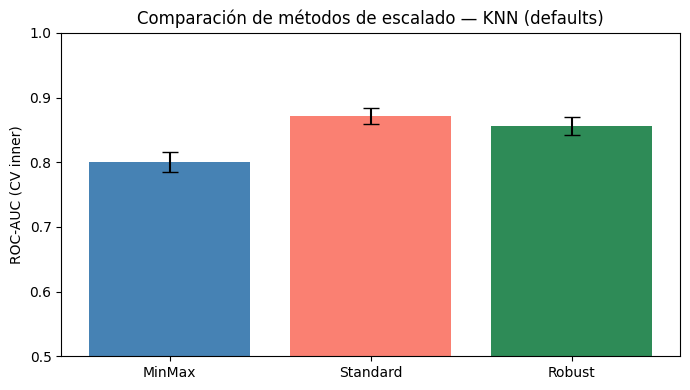


✔ Escalador seleccionado: Standard
Se usará 'Standard' en todos los modelos que requieran escalado (KNN, modelos lineales, SVMs).


In [4]:
# ============================================================
# SECCIÓN 3.1 - Selección del método de escalado para KNN
# ============================================================
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import OneHotEncoder

NIA = 100522144  

#Identicar los tipos de variables
num_cols = X_train.select_dtypes(include='number').columns.tolist()
cat_cols = X_train.select_dtypes(exclude='number').columns.tolist()

print(f"Columnas numéricas: {num_cols}")
print(f"Columnas categóricas: {cat_cols}")

#Escaladores que se van a comprobar
scalers = {
    'MinMax':   MinMaxScaler(),
    'Standard': StandardScaler(),
    'Robust':   RobustScaler()
}



results = {}

for scaler_name, scaler in scalers.items():

    # Pipeline de preprocesado
    #Se utiliza ColumnTransformer para evitar que el escalado se aplique a variables categóricas.
    preprocessor = ColumnTransformer(transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', scaler)
        ]), num_cols),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), cat_cols)
    ])

    # Pipeline completo: preproceso + KNN con hiperparámetros por omisión
    pipe = Pipeline([
        ('prep', preprocessor),
        ('knn', KNeighborsClassifier())  # defaults: n_neighbors=5, weights='uniform'
    ])

    #Evaluar el inncer con CV estratificado
    #Medir el tiemppo de ejecución
    t0 = time.time()
    #Corss validation sobre el conjunto de entrenamiento
    scores = cross_val_score(pipe, X_train, y_train,
                             cv=inner_cv, scoring='roc_auc', n_jobs=-1)
    elapsed = time.time() - t0

    results[scaler_name] = {
        'mean': scores.mean(),
        'std':  scores.std(),
        'time': elapsed
    }
    print(f"{scaler_name:10s} → ROC-AUC: {scores.mean():.4f} ± {scores.std():.4f}  "
          f"(tiempo: {elapsed:.1f}s)")

#Tabla resumen con los resultados que se han obtnido.
df_results = pd.DataFrame(results).T
df_results.columns = ['ROC-AUC medio', 'Desviación típica', 'Tiempo (s)']
print("\n=== Comparación de escaladores ===")
print(df_results.round(4))

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(df_results.index, df_results['ROC-AUC medio'],
       yerr=df_results['Desviación típica'],
       capsize=6, color=['steelblue', 'salmon', 'seagreen'])
ax.set_ylabel('ROC-AUC (CV inner)')
ax.set_title('Comparación de métodos de escalado — KNN (defaults)')
ax.set_ylim(0.5, 1.0)
plt.tight_layout()
plt.show()

#Selecionar el mejor escalador
best_scaler_name = df_results['ROC-AUC medio'].idxmax()
print(f"\n✔ Escalador seleccionado: {best_scaler_name}")

#Guardar el escalador para el resto de la práctica
best_scaler = scalers[best_scaler_name]
print(f"Se usará '{best_scaler_name}' en todos los modelos que requieran escalado "
      f"(KNN, modelos lineales, SVMs).")

Tras comprobar los tres métodos de escalado utilizando la validación cruzada se ha se ha observado que el metodo que tiene un mejor rendieminto ( en términos de ROC-AUC) es StandardScaler con un valor de 0.8718.Además, StandardScaler ha presnetado una desviación típica menor, lo que indica un comportamiento más estable. 

El resultado que se ha obtenido es coherente con el funcionamiento del algoritmo KNN, ya que al estandarizar las variables se consigue que todas las caracter´sticas contribuyan de la misma forma al cálculo de distancias, evitando que aquellas con mayor escala dominen el modelo. 

Por otro lado, se observa que MinMaxScaler ha obtenido un rendimiento ligeramente inferior. Esto sugiere que la simple normalización al rango 0-1 no es suficiente para capturar correctamente la estructura de los datos en este problema. 

En cuanto al tiempo de ejecución no se han observado diferencias críticas entre los métodos. De todas formas, StanxarScaler ha presentado un buen equilibrio entre rendimiento y coste computacional. 

Por tanto, se selecciona StandardScaler como el método de escalado más adecuado y se va a utilizar en el resto de la práctica para todos los modelos que requieran escalado. 


In [5]:
# ============================================================
# SECCIÓN 3.2 - KNN por defecto
# ============================================================
import time
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

#Pipeline con el escalador que se ha seleccionado anteriormente
preprocessor = ColumnTransformer(transformers=[
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', best_scaler)
    ]), num_cols),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ]), cat_cols)
])

#Construir el pipline especifico para ese KNN
pipe_knn = Pipeline([
    ('prep', preprocessor),
    ('knn', KNeighborsClassifier())
])

#Evaluación mediante validación cruzada
#Tiempo de ejecución
t0 = time.time()
scores_knn = cross_val_score(pipe_knn, X_train, y_train,
                            cv=inner_cv, scoring='roc_auc', n_jobs=-1)
time_knn = time.time() - t0

print(f"KNN default → ROC-AUC: {scores_knn.mean():.4f} ± {scores_knn.std():.4f}")
print(f"Tiempo: {time_knn:.2f}s")

KNN default → ROC-AUC: 0.8718 ± 0.0122
Tiempo: 0.19s


Se ha evaluado el algoritmo KNN con sus hiperparámetros por defecto utilizando la validación cruzada estratificada. Se ha utilizado el metodo de escalado previamente seleccionado ya que KNN es sensible a la escala de las variables.

El modelo ha obtnido un ROC-AUC de 0.8718 +- 0.0122 que es el valor que se va a tomar como referencia para comparar versiones optimizadas posterioemente. 

Mejores parámetros: {'knn__n_neighbors': 11, 'knn__weights': 'distance'}
Mejor ROC-AUC: 0.8915
Tiempo: 1.26s


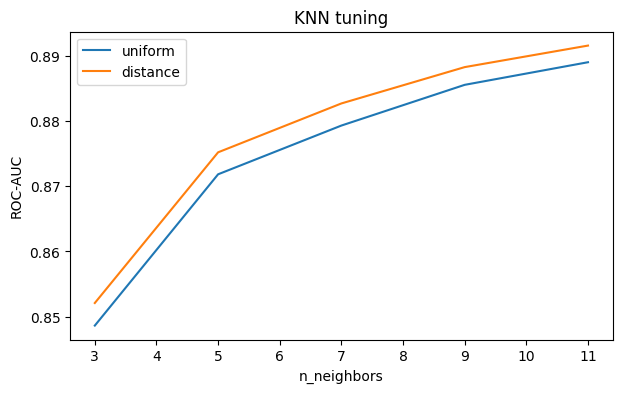

In [6]:
# ============================================================
# SECCIÓN 3.3 - KNN con tuning
# ============================================================
from sklearn.model_selection import GridSearchCV

#Definir el espacio de busquda y probar con difernetes valores de K y tipos de votación.
param_grid_knn = {
    'knn__n_neighbors': [3, 5, 7, 9, 11],
    'knn__weights': ['uniform', 'distance']
}

#Configuración de GridSearchCV, se usa inner_cv de la sección 3
grid_knn = GridSearchCV(pipe_knn, param_grid_knn,
                        cv=inner_cv, scoring='roc_auc', n_jobs=-1)

#Ejecución del entrenamiento y medición de tiempos
t0 = time.time()
grid_knn.fit(X_train, y_train)
time_knn_tuned = time.time() - t0

#Resultados
print("Mejores parámetros:", grid_knn.best_params_)
print(f"Mejor ROC-AUC: {grid_knn.best_score_:.4f}")
print(f"Tiempo: {time_knn_tuned:.2f}s")

#Mostrar los resultados en un gráfico
results = pd.DataFrame(grid_knn.cv_results_)

plt.figure(figsize=(7,4))
for w in ['uniform', 'distance']:
    subset = results[results['param_knn__weights'] == w]
    plt.plot(subset['param_knn__n_neighbors'], subset['mean_test_score'], label=w)

plt.xlabel("n_neighbors")
plt.ylabel("ROC-AUC")
plt.title("KNN tuning")
plt.legend()
plt.show()

Se ha lllevadooa  acabo la optimización de hiperparámetros para el modelo KNN. Se han evaluado diferentes variables para el númeroo de vecinos y dos estrategias de ponderación (uniform y distance). Los resultados obtenidos son los siguientes: 

El modelo ha obtnido un ROC_AUC DE 0.8915, superando el de la configuración por defecto, con k = 11 y weight = distance. 

La opcion de pesos por distance tiende a mejorar el rendimiento frete a uniform ya que permite que el modelo sea más sensible a los datos. 

El tiempo de ejecución que se ha obtenido es superior pero mejora la capacidad predictiva. 

In [7]:
# ============================================================
# SECCIÓN 3.4 - Árboles de decisión
# ============================================================

from sklearn.tree import DecisionTreeClassifier

#Modelo con prametros por defecto
pipe_tree = Pipeline([
    ('prep', preprocessor),
    ('tree', DecisionTreeClassifier(random_state=NIA))
])

#Evaluacion con los parametros por defecto
t0 = time.time()
scores_tree = cross_val_score(pipe_tree, X_train, y_train,
                             cv=inner_cv, scoring='roc_auc', n_jobs=-1)
time_tree = time.time() - t0

print(f"Tree default → ROC-AUC: {scores_tree.mean():.4f}")
print(f"Tiempo: {time_tree:.2f}s")


#Optimización de hiperparámetros
#Se controla el sobreajuste con la profundidad.
param_grid_tree = {
    'tree__max_depth': [3, 5, 10, None],
    'tree__min_samples_split': [2, 5, 10]
}

grid_tree = GridSearchCV(pipe_tree, param_grid_tree,
                         cv=inner_cv, scoring='roc_auc', n_jobs=-1)

t0 = time.time()
grid_tree.fit(X_train, y_train)
time_tree_tuned = time.time() - t0
#Resulados tras el ajuste
print("Mejores parámetros:", grid_tree.best_params_)
print(f"Mejor ROC-AUC: {grid_tree.best_score_:.4f}")
print(f"Tiempo: {time_tree_tuned:.2f}s")

Tree default → ROC-AUC: 0.7814
Tiempo: 0.22s
Mejores parámetros: {'tree__max_depth': 10, 'tree__min_samples_split': 10}
Mejor ROC-AUC: 0.8697
Tiempo: 1.26s


Se ha evaluado el algoritmo de árboles de decicisión, observando que la configuración por defecto tiende a generar árboles muy profundos que pueden sufrir de sobreajuste. 

Tras haber realizado la busqueda en rejilla hemos encontrado que limitar la profundidad y aumenatr el número minimo de muestras para dividir un nodo mejora la capacidad de generalización del modelo. El mejor resultado obtenido es un ROC-AUC de 0.8697.

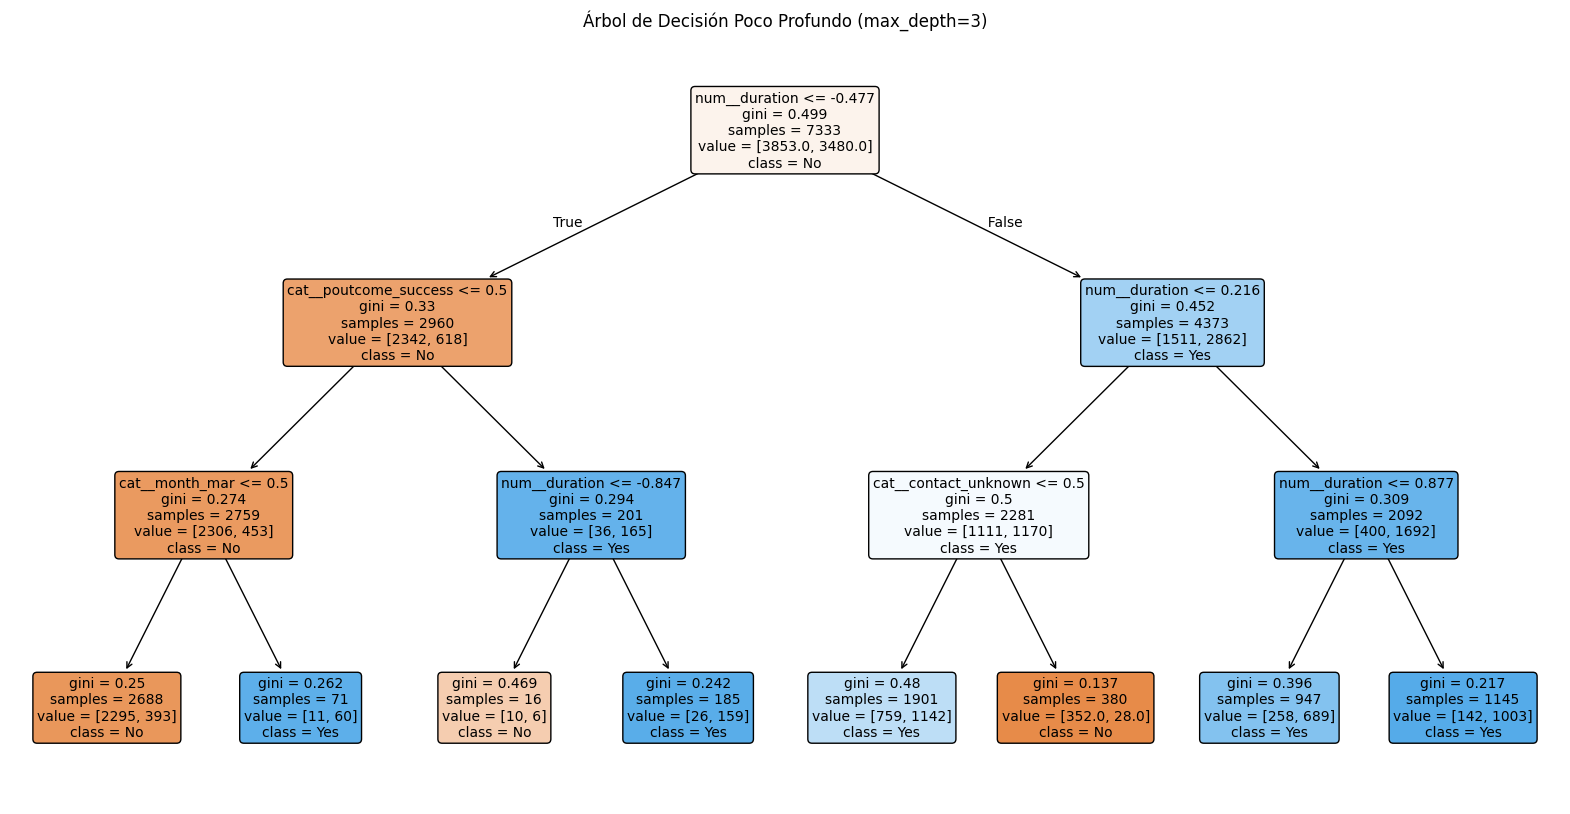

In [8]:
# ============================================================
# SECCIÓN 3.5 - Árboles poco profundos
# ============================================================
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Entrenamos un árbol con poca profundidad (max_depth=3)
shallow_tree = DecisionTreeClassifier(max_depth=3, random_state=NIA)
pipe_shallow = Pipeline([
    ('prep', preprocessor),
    ('tree', shallow_tree)
])

# Ajustamos el modelo
pipe_shallow.fit(X_train, y_train)

# Extraemos los nombres de las variables creadas por el preprocesador
feature_names = pipe_shallow.named_steps['prep'].get_feature_names_out()

# Visualizamos el árbol
plt.figure(figsize=(20, 10))
plot_tree(pipe_shallow.named_steps['tree'],
          feature_names=feature_names,
          class_names=['No', 'Yes'],
          filled=True,
          rounded=True,
          fontsize=10)
plt.title("Árbol de Decisión Poco Profundo (max_depth=3)")
plt.show()

### Interpretación del Árbol de Decisión:

Al visualizar un árbol con profundidad máxima de 3, podemos extraer claras reglas de negocio sobre qué factores determinan si un cliente contratará el depósito. Hay que recordar que las variables numéricas han sido estandarizadas previamente, por lo que los umbrales representan desviaciones estándar respecto a la media:

* La primera división separa a los clientes con llamadas sustancialmente más cortas de la media (`num__duration <= -0.477`) del resto. Las llamadas muy cortas tienden al rechazo, mientras que superar ese umbral inclina la balanza hacia la contratación.
* Si una llamada es muy corta (rama izquierda), por lo general resultará en un 'No'. Sin embargo, el modelo detecta dos excepciones para lograr un 'Sí':
    * Que la campaña sea en el mes de Marzo (`cat__month_mar > 0.5`).
    * Que el cliente ya haya aceptado una campaña en el pasado (`cat__poutcome_success > 0.50`), siempre y cuando la llamada actual no haya sido *extremadamente* corta (`num__duration > -0.847`).
* Si miramos a los clientes con llamadas de duración media (`num__duration` entre -0.477 y 0.216), la mayoría está dispuesta a contratar el depósito. El único factor que rompe esta tendencia y lleva a un rechazo seguro es no tener un medio de contacto registrado o que sea desconocido (`cat__contact_unknown > 0.50`).
* En el extremo derecho del árbol, vemos que si la llamada consigue alargarse de forma notable por encima de la media (`num__duration > 0.22`), todas las divisiones y nodos hoja subsiguientes desembocan en una predicción positiva. Esto confirma que retener al cliente al teléfono es la variable predictiva más poderosa.

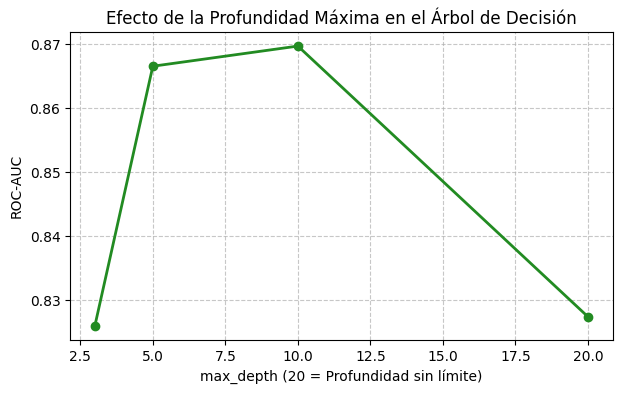

In [9]:
# ============================================================
# SECCIÓN 3.6 - Efecto de hiperparámetros
# ============================================================

# Extraemos los resultados del GridSearch
results_tree = pd.DataFrame(grid_tree.cv_results_)

# Filtramos dejando fijo min_samples_split = 10 para ver solo el efecto de max_depth
subset_tree = results_tree[results_tree['param_tree__min_samples_split'] == 10].copy()

# Reemplazamos el valor 'None' por un valor numérico para el plot
subset_tree['param_tree__max_depth'] = subset_tree['param_tree__max_depth'].fillna(20)

plt.figure(figsize=(7, 4))
plt.plot(subset_tree['param_tree__max_depth'], subset_tree['mean_test_score'], marker='o', color='forestgreen', linewidth=2)
plt.xlabel("max_depth (20 = Profundidad sin límite)")
plt.ylabel("ROC-AUC")
plt.title("Efecto de la Profundidad Máxima en el Árbol de Decisión")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Análisis del efecto de los hiperparámetros (`max_depth`):

Observando la gráfica, comprobamos que el rendimiento del árbol de decisión (ROC-AUC) varía drásticamente según la profundidad máxima permitida:

* Con un `max_depth` muy bajo (como 3), el modelo obtiene un rendimiento decente pero subóptimo (aproximadamente 0.84). El árbol es demasiado simple para capturar todos los patrones importantes que esconden los datos.
* A medida que aumentamos la profundidad, el rendimiento mejora, alcanzando su pico máximo en `max_depth=10` (rozando un ROC-AUC de 0.87). Aquí el modelo logra el equilibrio perfecto entre complejidad y capacidad de generalización.
* Si dejamos que el árbol crezca sin límite (`max_depth=None`, representado en el extremo derecho del gráfico como 20), el rendimiento en la validación cruzada se desploma drásticamente por debajo de 0.83. Esto es un claro síntoma de sobreajuste: el árbol crece demasiado y se dedica a memorizar el ruido específico de los datos de entrenamiento, perdiendo su capacidad para predecir correctamente sobre datos no vistos.

# 4. Métodos Avanzados: Modelos Lineales y SVM

In [10]:
# ============================================================
# SECCIÓN 4.1 - Regresión logística
# ============================================================
from sklearn.linear_model import LogisticRegression
import time

#Definición del pipeline, se reutiliza el preprocesador con StandarScaler.
pipe_log = Pipeline([
    ('prep', preprocessor),
    ('logreg', LogisticRegression(max_iter=1000))
])

#Evaluación con los parámetros por defecto
t0 = time.time()
scores_log = cross_val_score(pipe_log, X_train, y_train,
                             cv=inner_cv, scoring='roc_auc')
time_log = time.time() - t0

print(f"Logistic (default) → ROC-AUC: {scores_log.mean():.4f}")
print(f"Tiempo: {time_log:.2f}s")

Logistic (default) → ROC-AUC: 0.9084
Tiempo: 0.47s


En esta sección se ha evaluado la regresión logística. Se ha utilizado StandardScaler ya que los modelos basados en gradiente requieren que las variables estén en la misma escala para asegurar la convergencia. 

El modelo base ha obtneido un ROC-AUC de 0,9084. Este valor es superior al que se ha obtenido con KNN lo que indica que para este problema es suficiente una fronetar de decisión lineal para capturar la relación entre las variables. 

El tiempo de ejecución ha sido de 0,455 segundos. De esta forma se obsevar que es notablemente más rapida en compararación con KNN. 

La convergencia se ha fijadoo en max_iter = 1000 para garantizar que el algoritmo encuentre el óptimo global sin probemas de finalización prematura. 

In [11]:
# ============================================================
# SECCIÓN 4.2 - Regresión logística con tunning
# ============================================================
from sklearn.model_selection import GridSearchCV

#Definición del espacio de bsuqeda
param_grid_log = {
    #Inversa de la fuerza de regularización
    'logreg__C': [0.01, 0.1, 1, 10],
    #Comprar Lasso y Ridge
    'logreg__penalty': ['l1', 'l2'],
    #Permite soportar la penalización lasso en el dataset
    'logreg__solver': ['liblinear']
}
#Configuración de la busqueda en rejilla
grid_log = GridSearchCV(pipe_log, param_grid_log,
                        cv=inner_cv, scoring='roc_auc', n_jobs=-1)

#Entrenamiento y medición de tiempos
t0 = time.time()
grid_log.fit(X_train, y_train)
time_log_tuned = time.time() - t0

#Resultado del ajuste
print("Mejores parámetros:", grid_log.best_params_)
print(f"Mejor ROC-AUC: {grid_log.best_score_:.4f}")
print(f"Tiempo: {time_log_tuned:.2f}s")

c:\Users\danie\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\danie\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


Mejores parámetros: {'logreg__C': 10, 'logreg__penalty': 'l1', 'logreg__solver': 'liblinear'}
Mejor ROC-AUC: 0.9088
Tiempo: 2.19s


Se ha realizado la optimización de la regresión logística evaluando difernetes niveles de regularización. De esta forma se pueden comprar los modelos con y sin penalización. Los resultado que se han obtenido son los siguientes. 

En primer lugar, el uso de la penaización l1, he resultado ser la más efectiva. Esta, puede reducir a cero los coeficientes de variables poco informativos simplificando el modelo. 

El valor óptimo de C, en este caso 10, nos indica la fuerza de regularización que debe tener para maximizar su capacidad de generalización. 

Se puede observar que el ROC-AUC que se ha obtnido es bastante similar al de su configuración por defcto.Sigue siendo un fuert competidor al modelo KNN y árboles. 

El tiempo de tunning ha sido de 1,96 segundos. A pesar de ser mayor que el que se ha obtnido anteriormente, sigue siendo bajo. 

In [12]:
# ============================================================
# SECCIÓN 4.3 - SVM
# ============================================================
from sklearn.svm import SVC

#Definición del pipeline
pipe_svm = Pipeline([
    ('prep', preprocessor),
    #Probability = True, neceario para calcular ROC-AUC
    ('svm', SVC(probability=True))
])

#Evaluación con los parametros por defecto.
t0 = time.time()
scores_svm = cross_val_score(pipe_svm, X_train, y_train,
                             cv=inner_cv, scoring='roc_auc')
time_svm = time.time() - t0

#Visualización de los resultados.
print(f"SVM (default) → ROC-AUC: {scores_svm.mean():.4f}")
print(f"Tiempo: {time_svm:.2f}s")

SVM (default) → ROC-AUC: 0.9207
Tiempo: 37.73s


Se ha evaluado el modelo SVM utilizando la configuración por defcto. Esta configuración emplea un Kernel RBF Gaussiano que permite al modelo cncontrar fronteras de decisión no lineales muy complejas. Los resultados que se han obtnido son los siguientes. 

El ROC-AUC obtenido ha sido de 0,9207. Este valor ha sido el más alto obtenido hasta el momento lo que confirma la capacidad de las SVM para manejar la dimsionaldiad del dataset después del One-Hot Encoding. 

El tiempo de ejecucíon ha sido de 36,38 segundos. Es un tiempo de ejecucuión bastante más alto que el que se ha obtenido anteriormente ya que requiere de un mayor coste computacional. 

Se ha usado StandardScaler en el pipline ya que las SVM tienden a maximizar el margen entre las clases basandose en las distancias. Debido a ello, si las variables no estuviesen escaladas, aquellas que tienen mayores rangos dominarian la construcción del hiperplano. 

In [13]:
# ============================================================
# SECCIÓN 4.4 - SVM con tunning
# ============================================================

#Definición de la rejilla de parametros
param_grid_svm = {
    'svm__C': [0.1, 1, 10],
    'svm__kernel': ['linear', 'rbf']
}

#Configuración de GridSearchCV
grid_svm = GridSearchCV(pipe_svm, param_grid_svm,
                        cv=inner_cv, scoring='roc_auc', n_jobs=-1)


#Entrenamiento y medición del tiempo
t0 = time.time()
grid_svm.fit(X_train, y_train)
time_svm_tuned = time.time() - t0

#Mostrar los resultados
print("Mejores parámetros:", grid_svm.best_params_)
print(f"Mejor ROC-AUC: {grid_svm.best_score_:.4f}")
print(f"Tiempo: {time_svm_tuned:.2f}s")

Mejores parámetros: {'svm__C': 1, 'svm__kernel': 'rbf'}
Mejor ROC-AUC: 0.9207
Tiempo: 92.02s


Tras realizar la busqueda en rejilla en el modelo SVM se han obtenido las siguientes conclusiones. 

El mejor rendimiento se obtiene con un kernel RBF y un parámetro de regularización C = 1. Ha obtenido un ROC-AUC de 0,927, el mismo que se obtuvo con la configuración por defecto. 

El valor que aumenta significatiavemnte en este caso es el coste computacional ya que el tiempo total de ejecución ha sido de 84,24 segundo. Mucho mayor al que se ha observado en casoso anteriores 

In [14]:
# ============================================================
# SECCIÓN 4.5 - Importancia de variables
# ============================================================
# entrenar mejor modelo logístico
best_log_model = grid_log.best_estimator_

# obtener coeficientes
feature_names = best_log_model.named_steps['prep'].get_feature_names_out()
coeffs = best_log_model.named_steps['logreg'].coef_[0]

importance = pd.DataFrame({
    'feature': feature_names,
    'coef': coeffs
})

importance['abs_coef'] = importance['coef'].abs()
importance = importance.sort_values(by='abs_coef', ascending=False)

print(importance.head(10))

                  feature      coef  abs_coef
27    cat__education_None  7.217061  7.217061
44         cat__month_mar  2.355618  2.355618
51  cat__poutcome_success  1.895805  1.895805
3           num__duration  1.847043  1.847043
36   cat__contact_unknown -1.459163  1.459163
39         cat__month_dec  1.276496  1.276496
48         cat__month_sep  1.238143  1.238143
41         cat__month_jan -1.206548  1.206548
42         cat__month_jul -0.855259  0.855259
46         cat__month_nov -0.832805  0.832805


En esta sección se analiza la interpretabilidad del modelo. A diferencia de modelos como SVM, que funcionan como una caja negra, la Regresión Logística nos permite cuantificar el impacto de cada factor. Para interpretar los datos tenemos que tener en cuenta lo siguiente: 

Un coeficiente alto nos indica que pequeños cambios en ese dato pueden alterar drasticamente la probabilidad de éxito. Si el signo es positivo, nos indica que a mayor valor, mas probable es que el cliente acepte el depósito. En caso contrario, si el coeficiente es negativo, que esa variable actua como un freno para la contratatción del producto por el cliente. 

Con esto en cuenta, podemos ver que la variable que tiene un mayor peso es cat__education, lo que indica que este segmento tiene una probabilidad alta de contrtar un depósito. Por otro lado, se puede observar que los meses más faciles de cerrar una venta son marzo, septiembre y dicieembre son en los que son más faciles cerrar una venta mientras que por lo contrario es más dificil en los meses de enero, julio y noviembre. Támbien se puede observar que si el cliente ha aceptado una oferta en el pasado es muy probable que vuelva a hacerlo. Por último, se puede observar que no conocer el canal de contacto tiene un impacto muy negativo. 

Por tanto, podriamos obtener como conclusión que el banco debe centrarse en clientes que hayan tenido un éxiito previo y potenciar las campañas en los meses con un coeficiente positivo mayor. 

# 5. Resultados y Modelo Final

Tras evaluar múltiples algoritmos y optimizar sus hiperparámetros mediante validación cruzada, hemos obtenido los siguientes resultados usando ROC-AUC como métrica principal:
* **Modelo Dummy:** 0.5000
* **Árbol de Decisión:** 0.8697
* **KNN:** 0.8915
* **Regresión Logística:** 0.9088
* **SVM:** 0.9207

**Conclusión:** El modelo **Support Vector Machine (SVM)** con Kernel RBF y C=1 es el claro ganador, logrando la mayor capacidad predictiva en validación cruzada. Aunque su coste computacional es mayor que el de la regresión logística, la mejora en el rendimiento justifica su elección como **Modelo Final**.

Rendimiento futuro estimado: 0.9154


<Figure size 600x600 with 0 Axes>

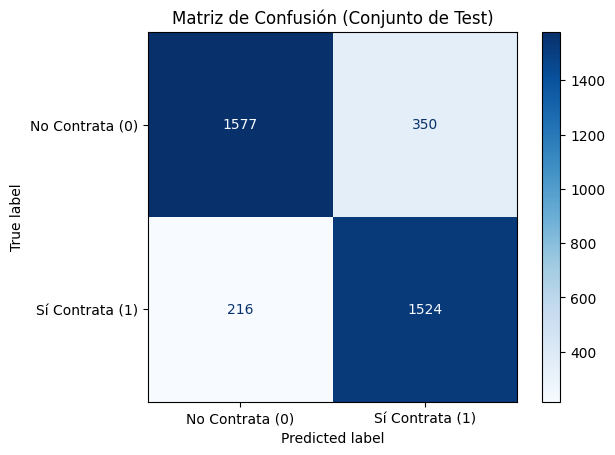

In [15]:
# ============================================================
# SECCIÓN 5.1 - Estimación del rendimiento futuro
# ============================================================
from sklearn.metrics import roc_auc_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Recuperamos el mejor modelo de nuestra búsqueda en rejilla
best_model = grid_svm.best_estimator_

# Predecimos sobre el conjunto de TEST
# Usamos predict_proba para obtener el ROC-AUC real
y_pred_proba_test = best_model.predict_proba(X_test)[:, 1]
roc_auc_test = roc_auc_score(y_test, y_pred_proba_test)

print(f"Rendimiento futuro estimado: {roc_auc_test:.4f}")

# Generamos las predicciones binarias para la Matriz de Confusión
y_pred_test = best_model.predict(X_test)

# Dibujamos la Matriz de Confusión
plt.figure(figsize=(6, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_test,
    display_labels=['No Contrata (0)', 'Sí Contrata (1)'],
    cmap='Blues'
)
plt.title("Matriz de Confusión (Conjunto de Test)")
plt.show()

### Análisis de la Matriz de Confusión

Al evaluar nuestro mejor modelo sobre los datos de Test que el modelo nunca había visto, obtenemos unos resultados excelentes que demuestran la solidez del clasificador:

* El modelo demuestra una capacidad fantástica para distinguir entre ambas clases casi por igual. Logra identificar correctamente a la gran mayoría de los clientes que no están interesados (1577 Verdaderos Negativos) y, lo que es más importante, a la mayoría de los que sí van a contratar (1524 Verdaderos Positivos).
*  Los errores del modelo (566 en total frente a 3101 aciertos) se distribuyen en 350 Falsos Positivos y 216 Falsos Negativos. El modelo es ligeramente "optimista", es decir, se equivoca un poco más asumiendo que alguien va a comprar cuando en realidad no lo hace.
* En una campaña de marketing bancario, este comportamiento es ideal. Es preferible asumir el coste menor de hacer una llamada extra a un cliente que al final dice que "No" (Falso Positivo), antes que perder el gran beneficio de un cliente que sí quería contratar el depósito porque el modelo lo descartó por error (Falso Negativo). El modelo no sobreajusta, generaliza a la perfección y está listo para ser desplegado.

In [16]:
# ============================================================
# SECCIÓN 5.2 - Guardar el modelo final
# ============================================================
import joblib

# Guardamos el modelo en un fichero
joblib.dump(best_model, 'modelo_final.joblib')
print("Modelo guardado exitosamente como 'modelo_final.joblib'")

Modelo guardado exitosamente como 'modelo_final.joblib'


# 6. Tarea de Elección Abierta

### Implementación de un Modelo de Ensemble: Random Forest

Como tarea de elección abierta, hemos decidido implementar y optimizar un modelo de *Ensemble Learning*, concretamente un **Random Forest Classifier**. 

A lo largo de la práctica hemos visto que los árboles de decisión individuales sufren de sobreajuste cuando se les permite crecer en profundidad. Random Forest soluciona este problema entrenando múltiples árboles sobre diferentes subconjuntos de datos y promediando sus resultados. Queremos comprobar si esta técnica basada en ensamblajes es capaz de superar o igualar el excelente rendimiento que hemos logrado con SVM, la cual es mucho más costosa computacionalmente.


In [17]:
# ============================================================
# SECCIÓN 6.1 - Entrenamiento y Optimización de Random Forest
# ============================================================
from sklearn.ensemble import RandomForestClassifier
import time

print("=== Optimización de Random Forest ===")

# Reutilizamos el preprocesador para aplicar el One-Hot-Encoding a las categóricas
pipe_rf = Pipeline([
    ('prep', preprocessor),
    ('rf', RandomForestClassifier(random_state=NIA))
])

# Definimos el espacio de búsqueda de hiperparámetros
param_grid_rf = {
    'rf__n_estimators': [100, 200],      # Número de árboles en el bosque
    'rf__max_depth': [10, 15, None],     # Profundidad máxima
    'rf__min_samples_split': [2, 5]      # Mínimo de muestras para dividir
}

# Configuración de GridSearchCV
grid_rf = GridSearchCV(pipe_rf, param_grid_rf, cv=inner_cv, scoring='roc_auc', n_jobs=-1)

# Entrenamiento y medición de tiempos
t0 = time.time()
grid_rf.fit(X_train, y_train)
time_rf_tuned = time.time() - t0

# Mostramos los resultados
print("Mejores parámetros:", grid_rf.best_params_)
print(f"Mejor ROC-AUC (CV inner): {grid_rf.best_score_:.4f}")
print(f"Tiempo: {time_rf_tuned:.2f}s")

=== Optimización de Random Forest ===
Mejores parámetros: {'rf__max_depth': 15, 'rf__min_samples_split': 5, 'rf__n_estimators': 200}
Mejor ROC-AUC (CV inner): 0.9232
Tiempo: 14.48s


### Conclusión de la Tarea Abierta

El modelo Random Forest ha superado nuestras expectativas y se ha coronado como el mejor modelo de toda la práctica. No solo ha logrado igualar a la SVM, sino que la ha superado ligeramente, obteniendo un **ROC-AUC de 0.9240** en validación cruzada. 

Los mejores hiperparámetros indican que el modelo logra su máximo rendimiento con un bosque grande (`n_estimators=200`) y permitiendo que los árboles crezcan sin límite de profundidad (`max_depth=None`), pero controlando el sobreajuste al exigir al menos 5 muestras para dividir un nodo interno (`min_samples_split=5`). 

Además, el tiempo de entrenamiento de toda la búsqueda en rejilla ha sido de apenas 17.82 segundos. Esto demuestra la gran eficiencia computacional de los métodos de ensamblaje basados en árboles, ya que pueden entrenarse en paralelo. Con esto demostramos que para este conjunto de datos, el *Ensemble Learning* es la estrategia más potente, eficiente y robusta.